<a href="https://colab.research.google.com/github/Sanjaiguru06/ML-Practice-Experiments/blob/main/Experiment_6PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

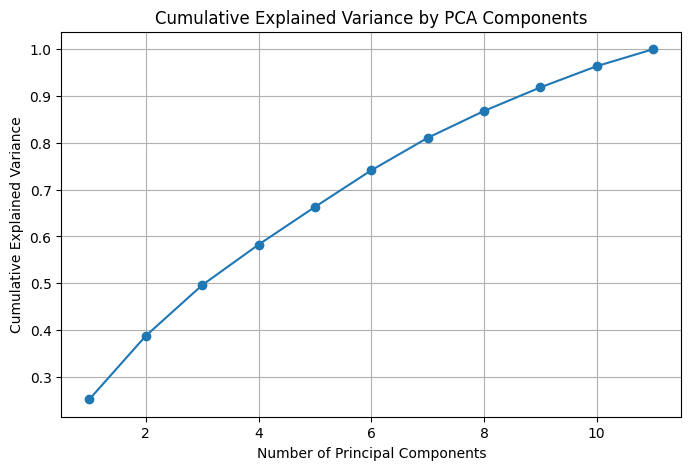

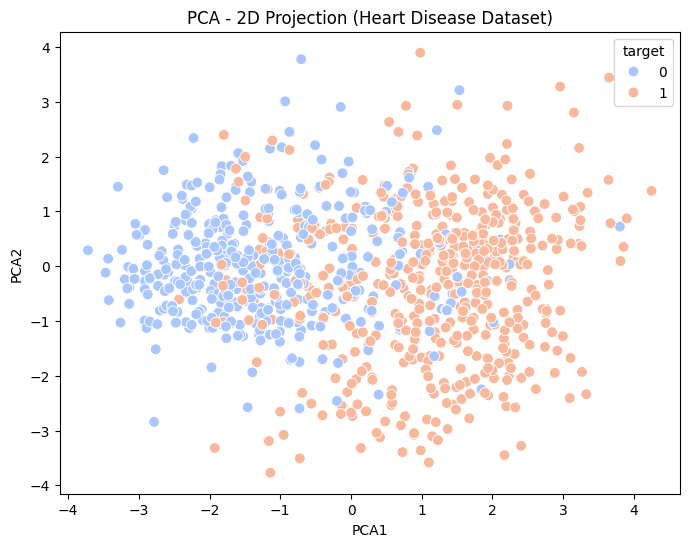

                         PCA1      PCA2
age                  0.322085  0.197622
sex                  0.192214 -0.344829
chest pain type      0.345598 -0.118454
resting bp s         0.168911  0.346223
cholesterol         -0.132074  0.585304
fasting blood sugar  0.168470 -0.228232
resting ecg          0.085784  0.430939
max heart rate      -0.400734  0.205662
exercise angina      0.415948  0.023338
oldpeak              0.375634  0.282618
ST slope             0.428323  0.071020
PCA completed successfully. Output saved as 'PCA_output.csv'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("/content/sample_data/dataset.csv")
X = df.drop(columns=["target"])
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=None)
X_pca = pca.fit_transform(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca_2, columns=["PCA1", "PCA2"])
pca_df["target"] = y

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PCA1", y="PCA2", hue="target", palette="coolwarm", s=60)
plt.title("PCA - 2D Projection (Heart Disease Dataset)")
plt.show()

loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PCA1", "PCA2"],
    index=X.columns
)
print(loadings)

pca_df.to_csv("PCA_output.csv", index=False)
print("PCA completed successfully. Output saved as 'PCA_output.csv'")
